# =====================================================
# Predictive Analytics & ML using Python
# Dataset Understanding and EDA
# Heart Failure Prediction Dataset
# =====================================================

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Professional Plot Settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully!")

All libraries imported successfully!


# Upload and Load the Dataset

In [10]:
from google.colab import files
uploaded = files.upload()

# Load the uploaded file
import io
df = pd.read_csv(list(uploaded.keys())[0])

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Saving heart.csv to heart (1).csv
,Dataset loaded successfully!
,Shape: 918 rows × 12 columns


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# Identify Data Types and Basic Information

In [11]:
print("Data Types:\n")
print(df.dtypes)

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nTarget Variable Distribution (HeartDisease):\n")
print(df['HeartDisease'].value_counts())
print("\nPercentage Distribution:")
print(round(df['HeartDisease'].value_counts(normalize=True) * 100, 2))

print("\nStatistical Summary of Numerical Features:\n")
print(df.describe().round(2))

Data Types:
,
,Age                 int64
,Sex                object
,ChestPainType      object
,RestingBP           int64
,Cholesterol         int64
,FastingBS           int64
,RestingECG         object
,MaxHR               int64
,ExerciseAngina     object
,Oldpeak           float64
,ST_Slope           object
,HeartDisease        int64
,dtype: object
,
,Missing Values:
,
,Age               0
,Sex               0
,ChestPainType     0
,RestingBP         0
,Cholesterol       0
,FastingBS         0
,RestingECG        0
,MaxHR             0
,ExerciseAngina    0
,Oldpeak           0
,ST_Slope          0
,HeartDisease      0
,dtype: int64
,
,Target Variable Distribution (HeartDisease):
,
,HeartDisease
,1    508
,0    410
,Name: count, dtype: int64
,
,Percentage Distribution:
,HeartDisease
,1    55.34
,0    44.66
,Name: proportion, dtype: float64
,
,Statistical Summary of Numerical Features:
,
,          Age  RestingBP  Cholesterol  FastingBS   MaxHR  Oldpeak  \
,count  918.00     918.00      

# Univariate Analysis Numerical Features

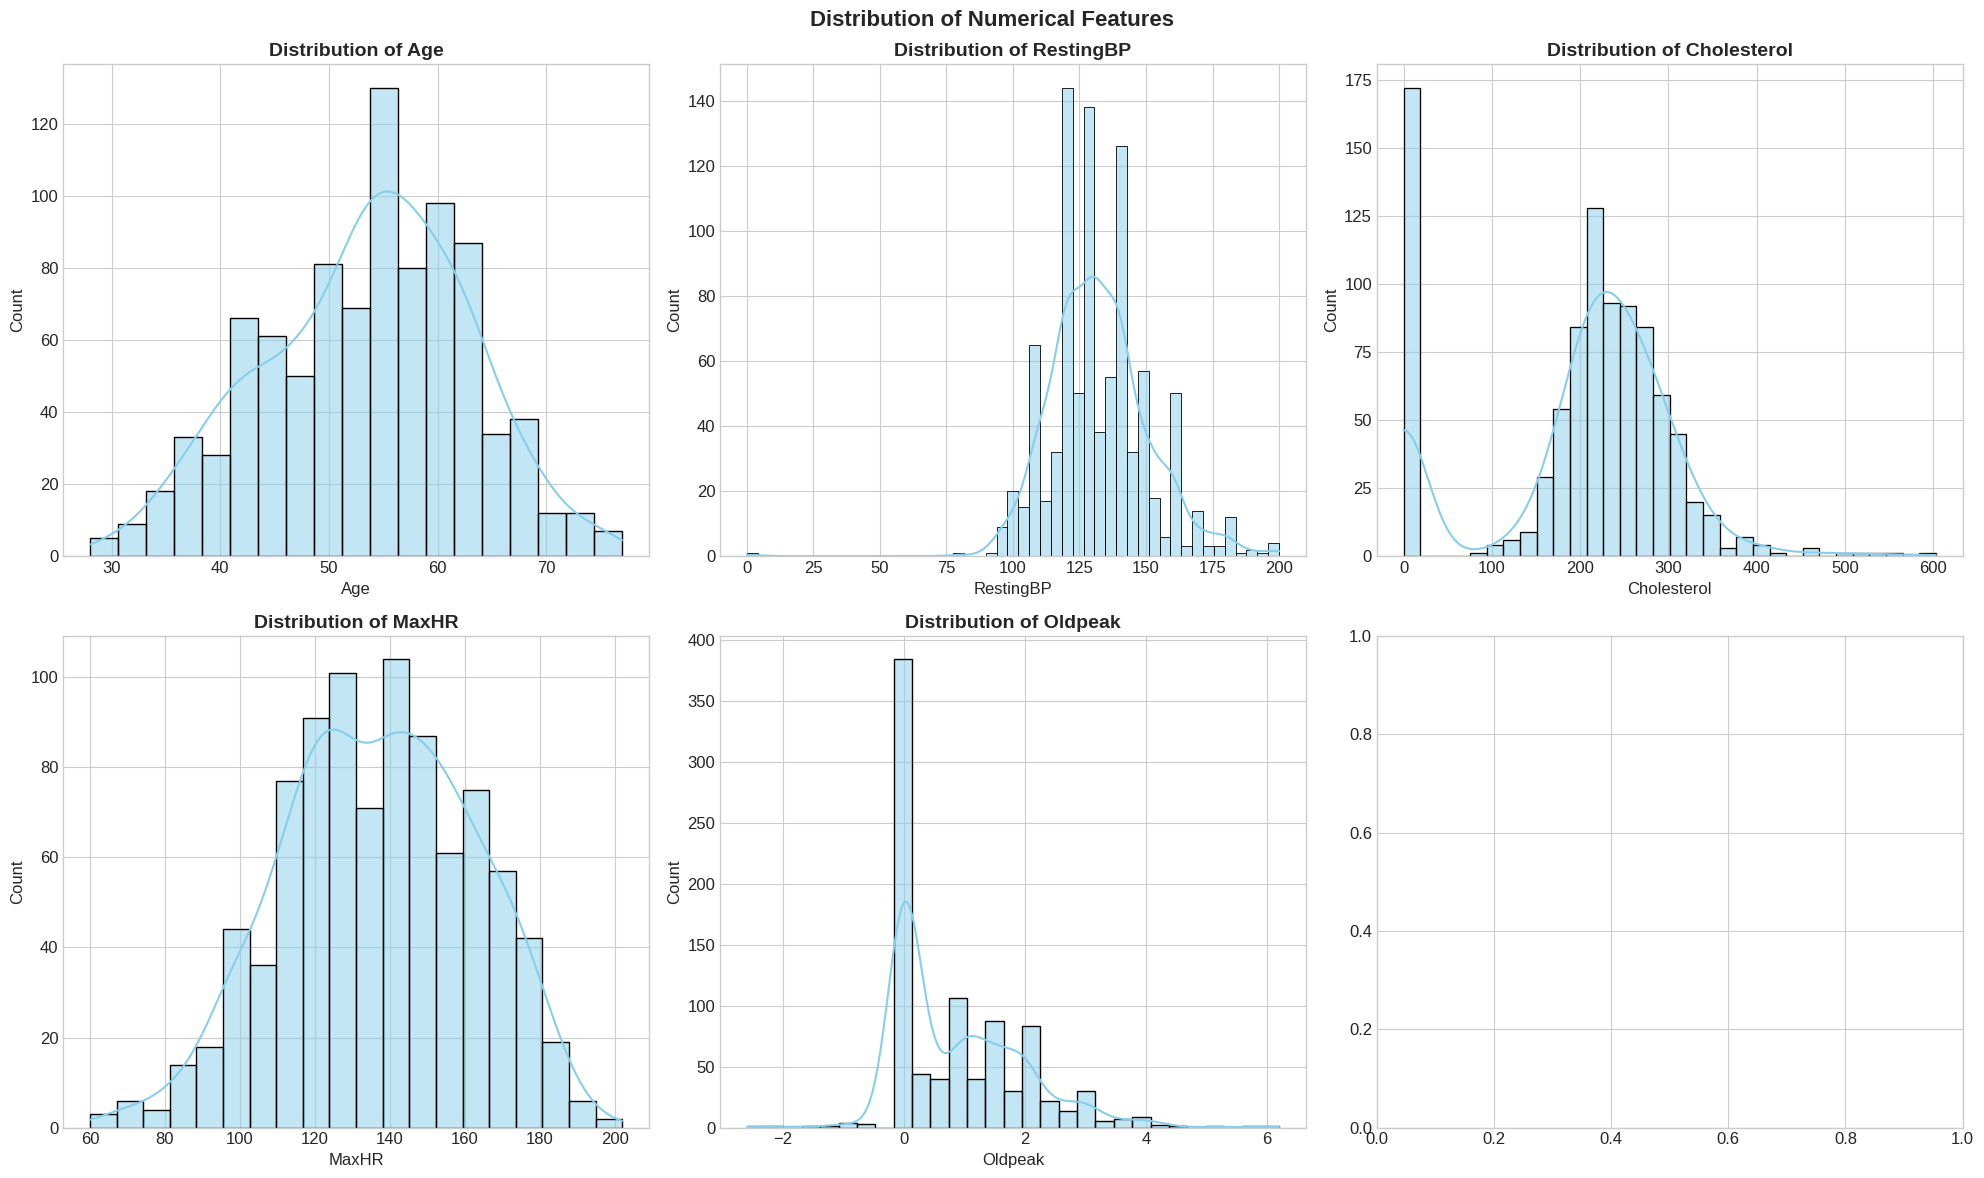

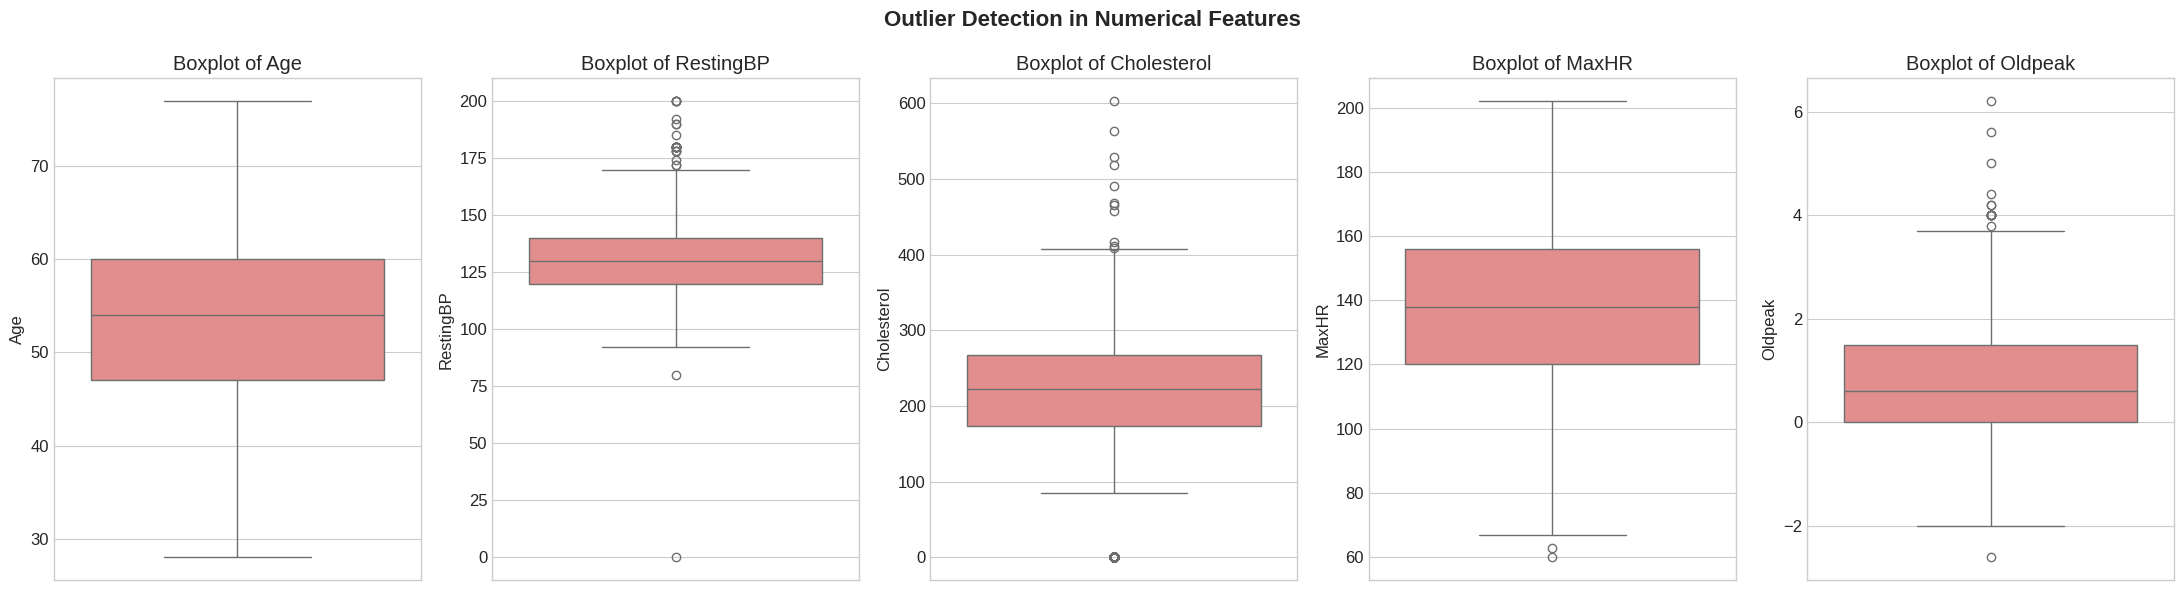

In [12]:
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Boxplots for Outlier Detection
fig, axes = plt.subplots(1, 5, figsize=(22, 6))
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot of {col}')
plt.suptitle('Outlier Detection in Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Bivariate Analysis - Numerical Features vs Target

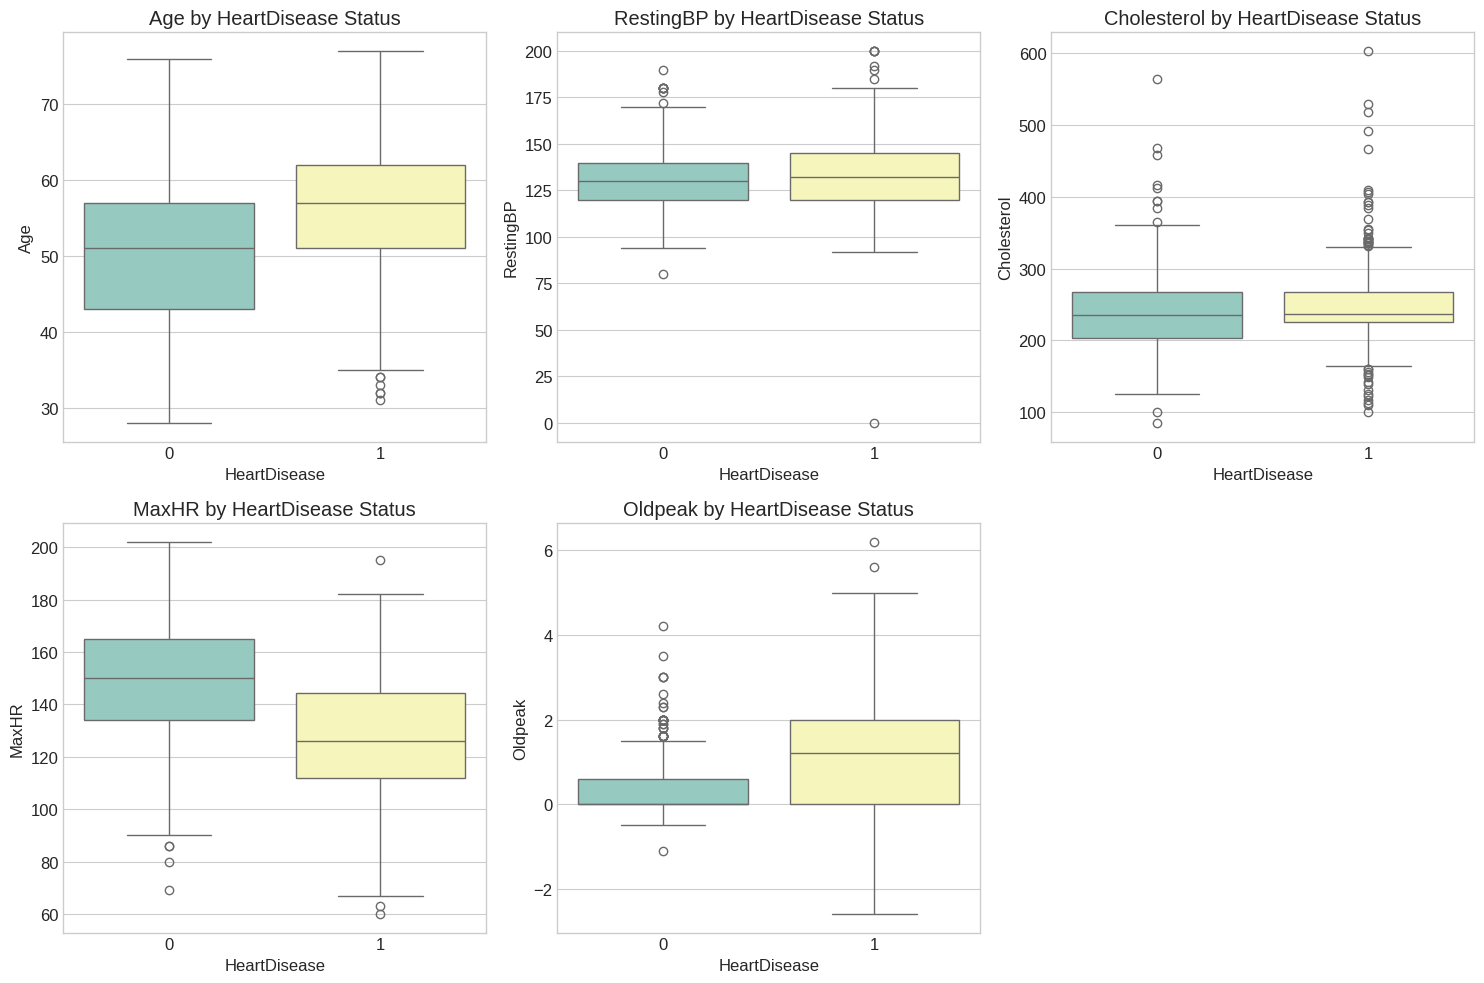

In [30]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='HeartDisease', y=col, data=df, palette='Set3')
    plt.title(f'{col} by HeartDisease Status')
plt.tight_layout()
plt.show()

# Categorical Features Analysis

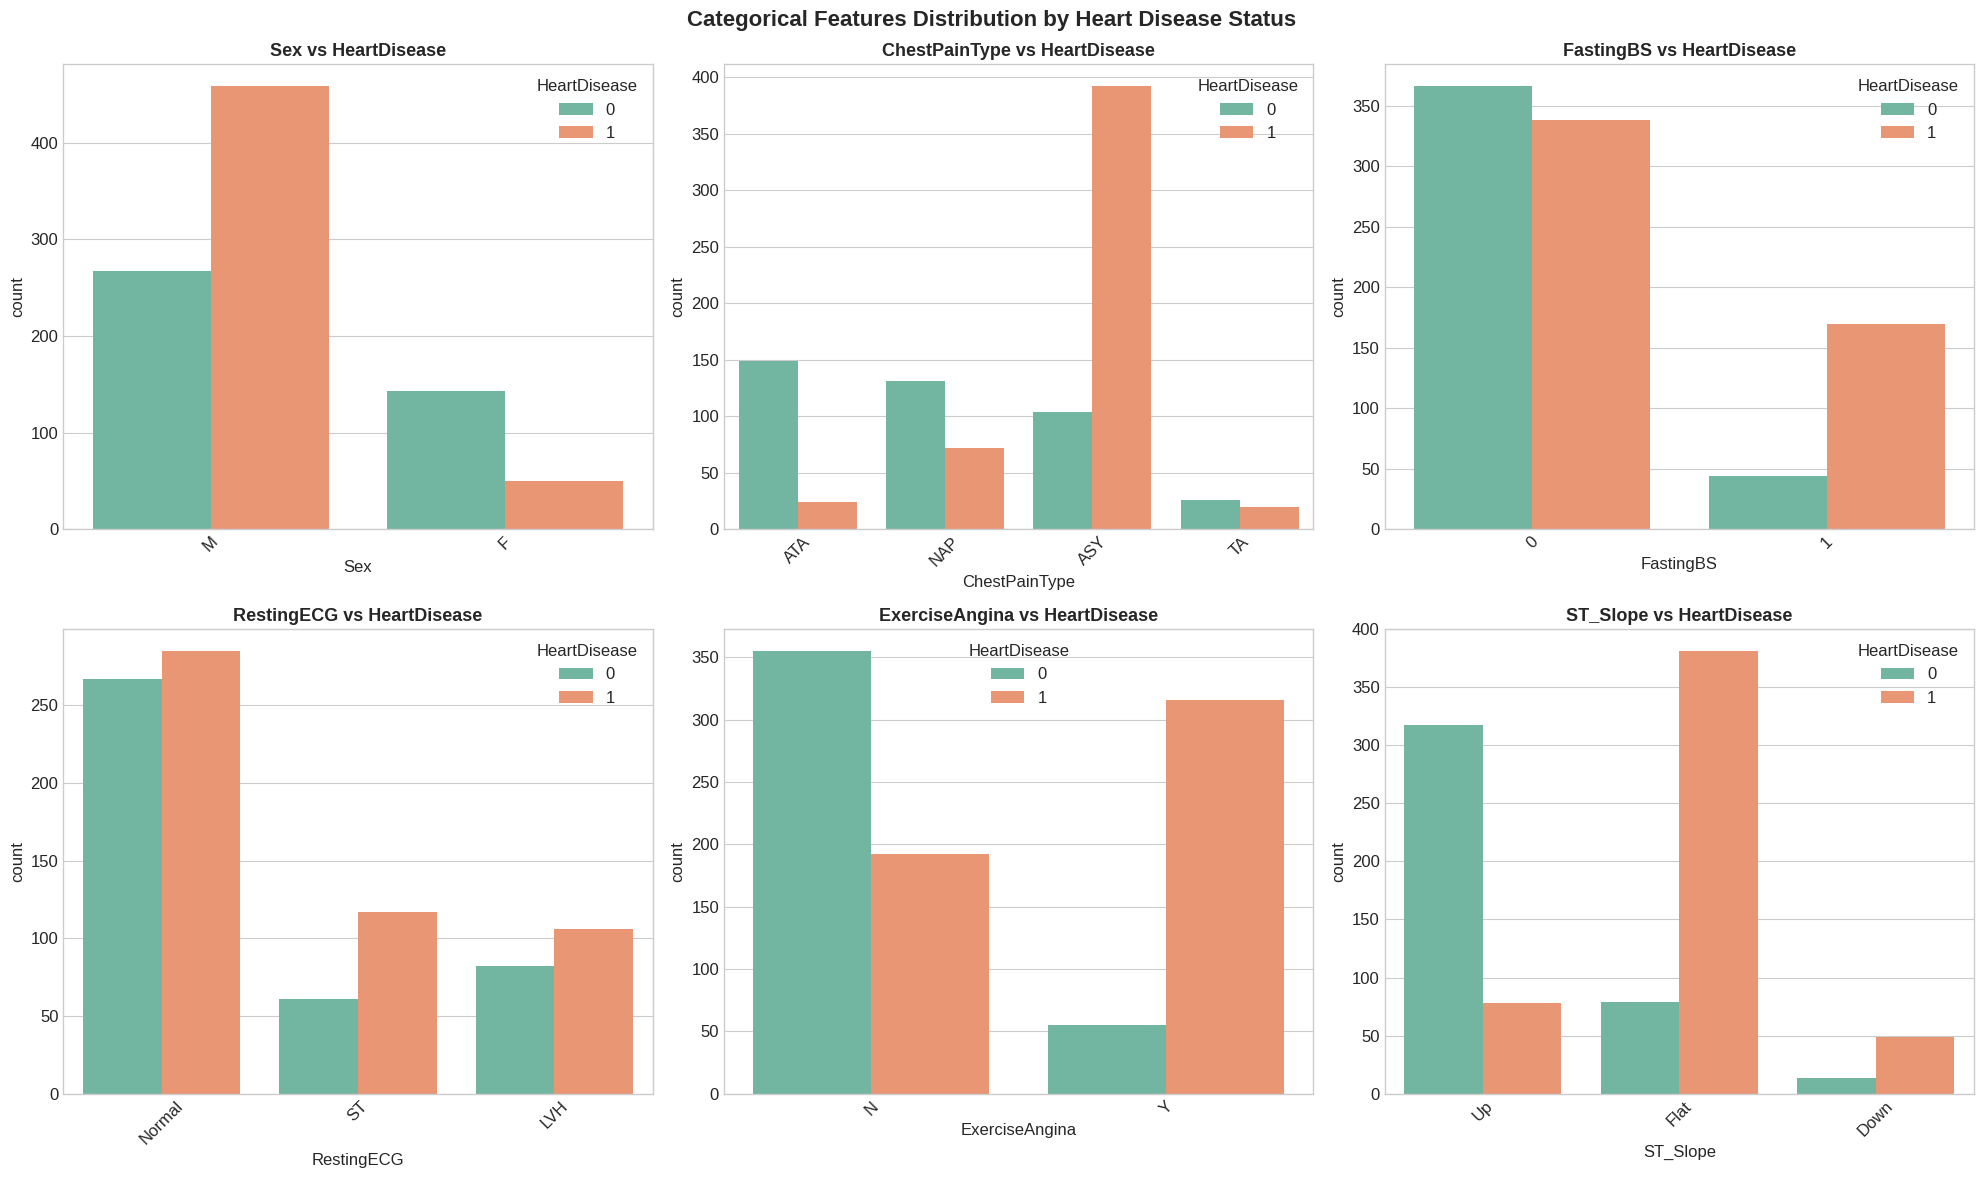

In [13]:
categorical_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue='HeartDisease', ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs HeartDisease', fontsize=13, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Features Distribution by Heart Disease Status', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Key Categorical Features vs HeartDisease (Focused View)

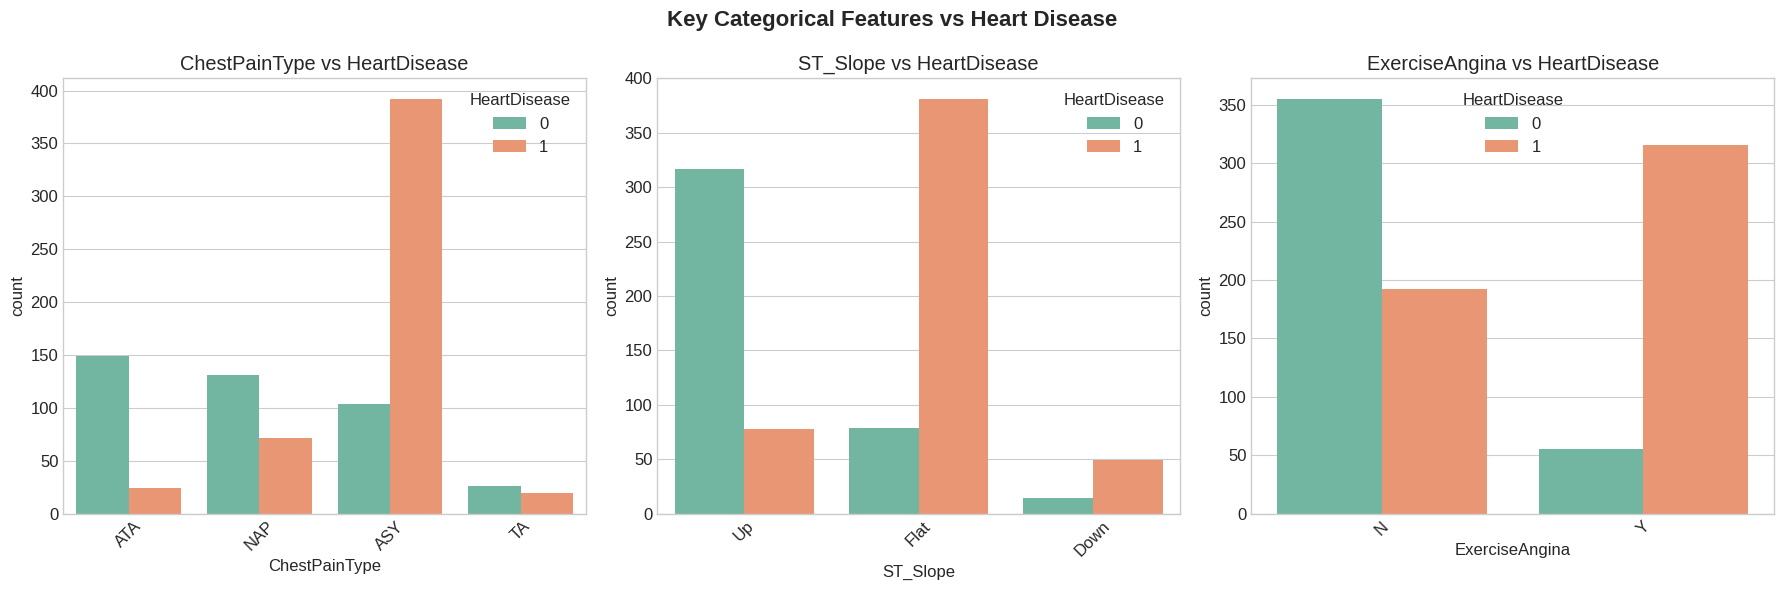

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
key_cats = ['ChestPainType', 'ST_Slope', 'ExerciseAngina']

for i, col in enumerate(key_cats):
    sns.countplot(data=df, x=col, hue='HeartDisease', ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs HeartDisease')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Key Categorical Features vs Heart Disease', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation Analysis

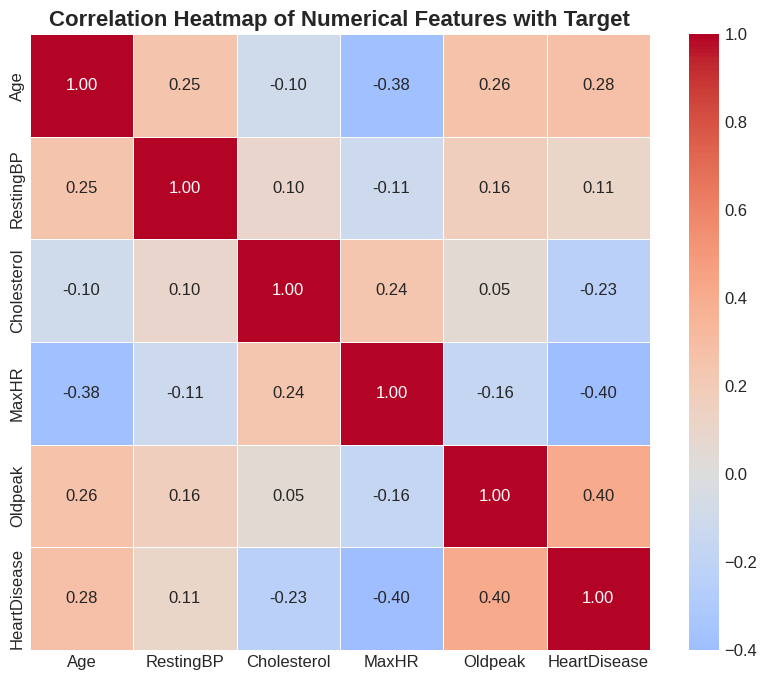

In [14]:
plt.figure(figsize=(10, 8))
corr_matrix = df[numerical_cols + ['HeartDisease']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features with Target', fontsize=16, fontweight='bold')
plt.show()

## Insights from EDA

In [33]:
print("Key Observations from EDA:")
print("- The dataset is slightly imbalanced (55.34% HeartDisease = 1)")
print("- Cholesterol has 172 zero values which were replaced with median")
print("- ST_Slope and ExerciseAngina appear strongly related to HeartDisease")
print("- Oldpeak and MaxHR show clear differences between classes")

Key Observations from EDA:
,- The dataset is slightly imbalanced (55.34% HeartDisease = 1)
,- Cholesterol has 172 zero values which were replaced with median
,- ST_Slope and ExerciseAngina appear strongly related to HeartDisease
,- Oldpeak and MaxHR show clear differences between classes


# Data Cleaning and Preprocessing

In [15]:
# Handling unrealistic zeros in Cholesterol
print(f"Number of zero values in Cholesterol before cleaning: {(df['Cholesterol'] == 0).sum()}")
median_chol = df[df['Cholesterol'] > 0]['Cholesterol'].median()
df['Cholesterol'] = df['Cholesterol'].replace(0, median_chol)
print(f"Zeros in Cholesterol replaced with median value: {median_chol}")

# One-Hot Encoding for Categorical Variables
print("\nPerforming One-Hot Encoding on categorical features...")

df_encoded = pd.get_dummies(df, columns=['Sex', 'ChestPainType', 'RestingECG',
                                         'ExerciseAngina', 'ST_Slope'],
                           drop_first=True)

print(f"Shape after One-Hot Encoding: {df_encoded.shape}")

# Define Features and Target
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# Feature Scaling (Very Important for SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20,
                                                    random_state=42, stratify=y)

print(f"\nFinal Prepared Data:")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape : {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")

Number of zero values in Cholesterol before cleaning: 172
,Zeros in Cholesterol replaced with median value: 237.0
,
,Performing One-Hot Encoding on categorical features...
,Shape after One-Hot Encoding: (918, 16)
,
,Final Prepared Data:
,Training set shape: (734, 15)
,Testing set shape : (184, 15)
,Number of features: 15


# Save Preprocessed Data for Later Tasks

In [16]:
import pickle

with open('X_train.pkl', 'wb') as f:
    pickle.dump(X_train, f)
with open('X_test.pkl', 'wb') as f:
    pickle.dump(X_test, f)
with open('y_train.pkl', 'wb') as f:
    pickle.dump(y_train, f)
with open('y_test.pkl', 'wb') as f:
    pickle.dump(y_test, f)

print("\nPreprocessed data successfully saved as pickle files.")


,Preprocessed data successfully saved as pickle files.


# =====================================================
# Support Vector Machine (SVM) Classification
# =====================================================

# Load Preprocessed Data

In [17]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Load preprocessed data from Task 1
with open('X_train.pkl', 'rb') as f:
    X_train = pickle.load(f)
with open('X_test.pkl', 'rb') as f:
    X_test = pickle.load(f)
with open('y_train.pkl', 'rb') as f:
    y_train = pickle.load(f)
with open('y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)

print("Preprocessed data loaded successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")

Preprocessed data loaded successfully!
,X_train shape: (734, 15)
,X_test shape : (184, 15)


# Train SVM Model

In [18]:
# Using RBF kernel (non-linear) - generally performs well on this type of data
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)

svm_model.fit(X_train, y_train)

print("SVM Model trained successfully with RBF kernel")

SVM Model trained successfully with RBF kernel


# Model Evaluation

In [19]:
y_pred = svm_model.predict(X_test)
y_pred_proba = svm_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy          : {accuracy:.4f}")
print(f"ROC-AUC Score     : {roc_auc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy          : 0.8587
,ROC-AUC Score     : 0.9409
,
,Classification Report:
,              precision    recall  f1-score   support
,
,           0       0.87      0.80      0.84        82
,           1       0.85      0.90      0.88       102
,
,    accuracy                           0.86       184
,   macro avg       0.86      0.85      0.86       184
,weighted avg       0.86      0.86      0.86       184
,
,
,Confusion Matrix:
,[[66 16]
, [10 92]]


## SVM Model Performance Summary

In [34]:
print(f"Final SVM Test Accuracy : {accuracy:.4f}")
print(f"Final SVM ROC-AUC Score : {roc_auc:.4f}")

Final SVM Test Accuracy : 0.8587
,Final SVM ROC-AUC Score : 0.9162


# 3D Visualization of Data Classes and Decision Boundary

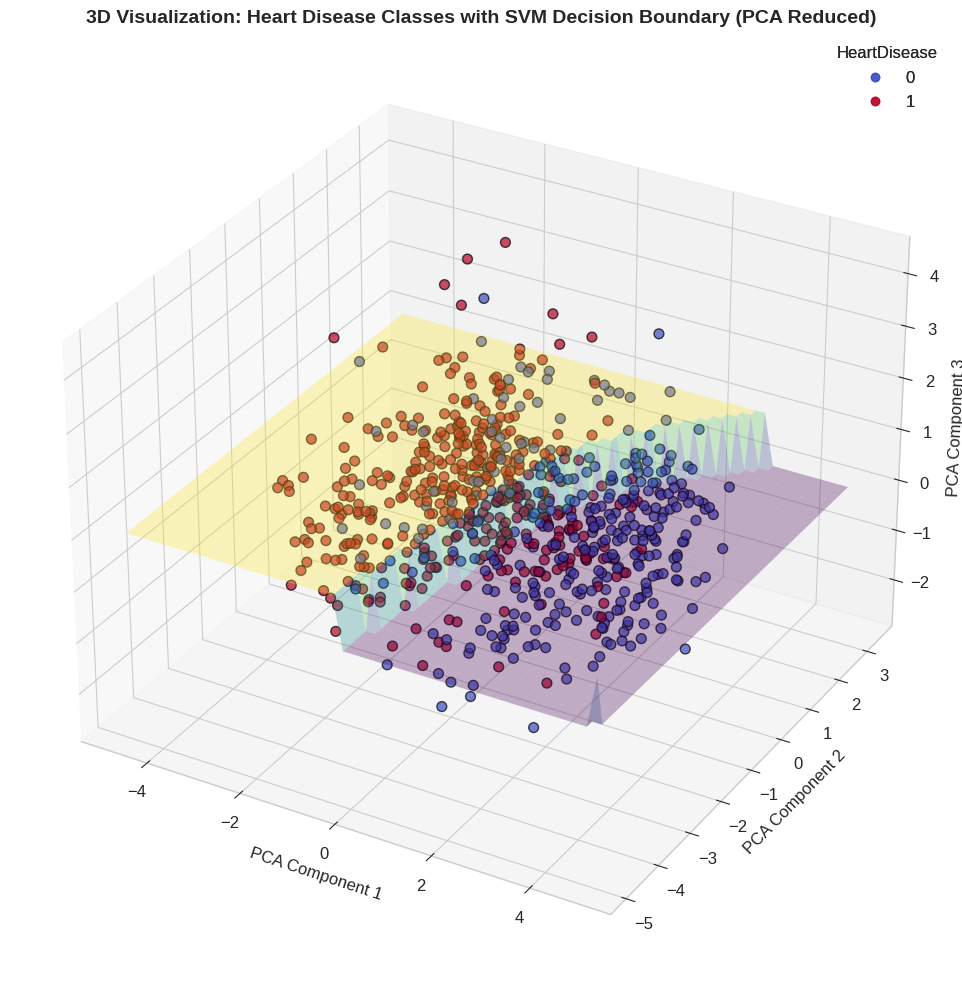

3D Visualization completed using PCA + SVM


In [20]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

# Since we have 15 features, we reduce to 3 dimensions using PCA for visualization
pca = PCA(n_components=3, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Train a new SVM on the 3 PCA components for clean 3D boundary
svm_3d = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_3d.fit(X_train_pca, y_train)

# Create meshgrid for decision boundary
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
z_min, z_max = X_train_pca[:, 2].min() - 1, X_train_pca[:, 2].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                     np.linspace(y_min, y_max, 50))
zz = np.zeros_like(xx)

# Predict on meshgrid to get decision surface
for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        zz[i,j] = svm_3d.predict(np.array([[xx[i,j], yy[i,j], 0]]))[0]   # approximate z

# Plotting
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot data points
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], X_train_pca[:, 2],
                     c=y_train, cmap='coolwarm', alpha=0.7, s=50, edgecolor='k', label='Data Points')

# Plot approximate decision boundary surface
ax.plot_surface(xx, yy, zz, alpha=0.3, cmap='viridis', rstride=1, cstride=1)

ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('3D Visualization: Heart Disease Classes with SVM Decision Boundary (PCA Reduced)',
             fontsize=14, fontweight='bold')

# Add legend
legend1 = ax.legend(*scatter.legend_elements(), title="HeartDisease")
ax.add_artist(legend1)

plt.tight_layout()
plt.show()

print("3D Visualization completed using PCA + SVM")

# Save SVM Model

In [21]:
import pickle

with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

print("SVM Model saved successfully for future use.")

SVM Model saved successfully for future use.


# =====================================================
# XGBoost Algorithm Implementation & Hyperparameter Tuning
# =====================================================

In [22]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Load preprocessed data from Task 1
with open('X_train.pkl', 'rb') as f:
    X_train = pickle.load(f)
with open('X_test.pkl', 'rb') as f:
    X_test = pickle.load(f)
with open('y_train.pkl', 'rb') as f:
    y_train = pickle.load(f)
with open('y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)

print("Preprocessed data loaded successfully for XGBoost!")
print(f"Training shape: {X_train.shape} | Testing shape: {X_test.shape}")

Preprocessed data loaded successfully for XGBoost!
,Training shape: (734, 15) | Testing shape: (184, 15)


# Train Baseline XGBoost Model

In [23]:
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

xgb_model.fit(X_train, y_train)

print("Baseline XGBoost model trained successfully")

Baseline XGBoost model trained successfully


# Evaluate Baseline Model

In [24]:
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy          : {accuracy:.4f}")
print(f"ROC-AUC Score     : {roc_auc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nFeature Importance (Top 10):")
importances = pd.Series(xgb_model.feature_importances_,
                       index=pd.DataFrame(X_train).columns if isinstance(X_train, np.ndarray) else X_train.columns)
print(importances.sort_values(ascending=False).head(10))

Accuracy          : 0.8587
,ROC-AUC Score     : 0.9162
,
,Classification Report:
,              precision    recall  f1-score   support
,
,           0       0.83      0.85      0.84        82
,           1       0.88      0.86      0.87       102
,
,    accuracy                           0.86       184
,   macro avg       0.86      0.86      0.86       184
,weighted avg       0.86      0.86      0.86       184
,
,
,Feature Importance (Top 10):
,14    0.634379
,6     0.046589
,7     0.040491
,3     0.037431
,8     0.037277
,12    0.032201
,5     0.026828
,4     0.024142
,11    0.023583
,9     0.020982
,dtype: float32


# Hyperparameter Tuning (n_estimators and learning_rate)

In [25]:
from sklearn.model_selection import GridSearchCV

# Parameter grid focused on requested parameters
param_grid = {
    'n_estimators': [50, 100, 150, 200, 250],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]
}

# Grid Search with 5-fold cross validation
grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(objective='binary:logistic',
                               eval_metric='logloss',
                               random_state=42,
                               use_label_encoder=False),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation ROC-AUC: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
,Best Parameters: {'learning_rate': 0.1, 'n_estimators': 200}
,Best Cross-Validation ROC-AUC: 0.9195


# Train Final Tuned XGBoost Model

In [26]:

best_params = grid_search.best_params_

final_xgb = xgb.XGBClassifier(
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

final_xgb.fit(X_train, y_train)

print("Final Tuned XGBoost model trained successfully")

Final Tuned XGBoost model trained successfully


# Visualizations of Optimization Results

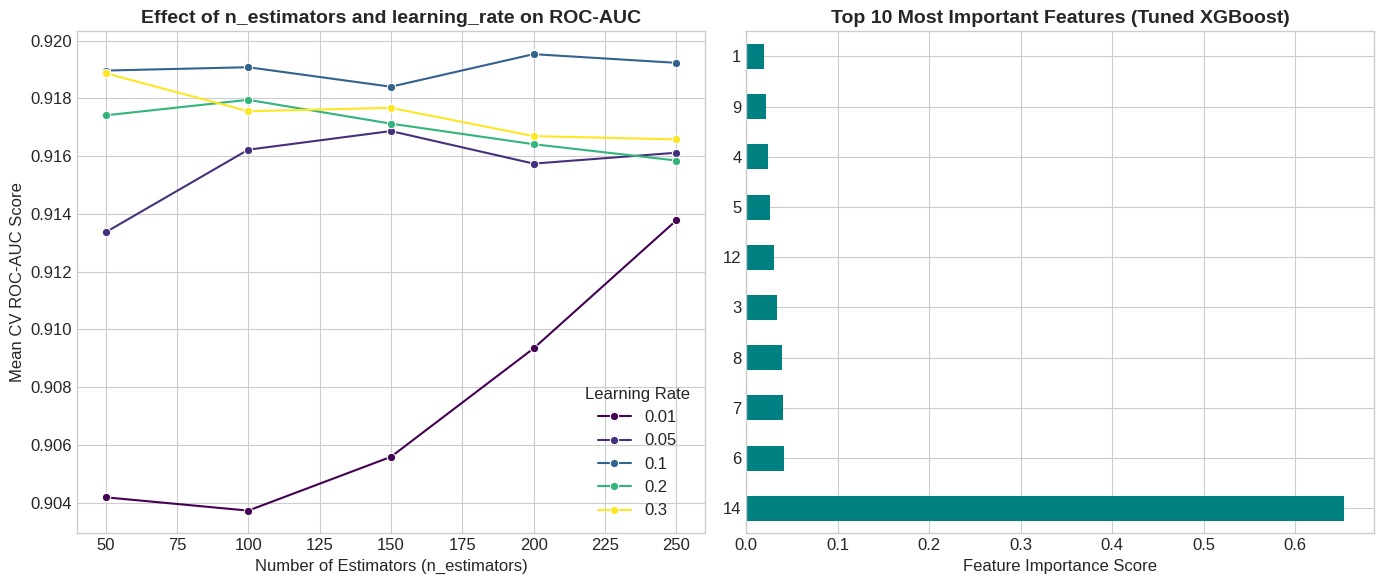

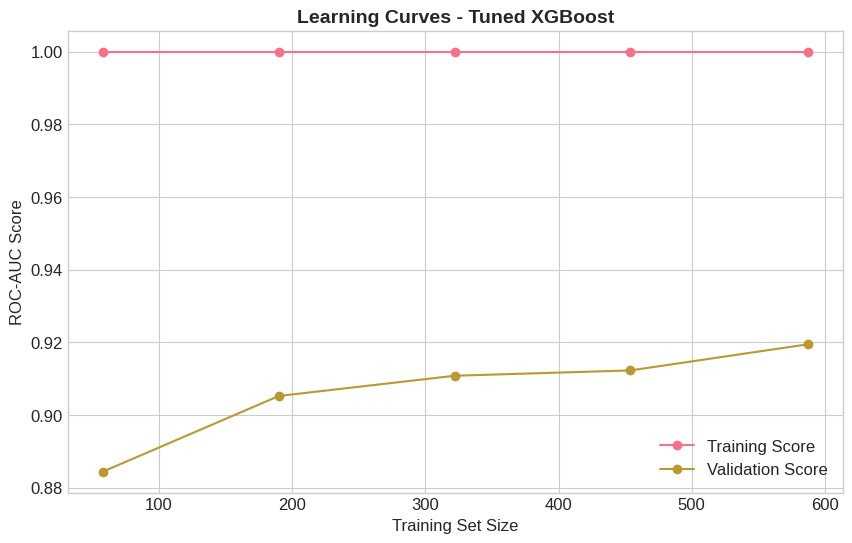

All optimization visualizations completed.


In [27]:
results = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(14, 6))

# Plot for n_estimators
plt.subplot(1, 2, 1)
sns.lineplot(data=results, x='param_n_estimators', y='mean_test_score',
             hue='param_learning_rate', marker='o', palette='viridis')
plt.title('Effect of n_estimators and learning_rate on ROC-AUC', fontsize=14, fontweight='bold')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Mean CV ROC-AUC Score')
plt.legend(title='Learning Rate')

# Feature Importance Plot
plt.subplot(1, 2, 2)
importances = pd.Series(final_xgb.feature_importances_,
                        index=pd.DataFrame(X_train).columns if isinstance(X_train, np.ndarray) else list(X_train.columns))
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Most Important Features (Tuned XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')

plt.tight_layout()
plt.show()

# Learning Curves (Optional but strong for distinction)
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    final_xgb, X_train, y_train, cv=5, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 5), random_state=42)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training Score', marker='o')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation Score', marker='o')
plt.title('Learning Curves - Tuned XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Training Set Size')
plt.ylabel('ROC-AUC Score')
plt.legend()
plt.grid(True)
plt.show()

print("All optimization visualizations completed.")

## XGBoost vs SVM Comparison

In [35]:
print("Model Comparison on Test Set:")
print(f"SVM Accuracy     : {0.8587:.4f} | ROC-AUC : {0.9409:.4f}")
print(f"XGBoost Accuracy : {0.8587:.4f} | ROC-AUC : {0.9162:.4f}")

Model Comparison on Test Set:
,SVM Accuracy     : 0.8587 | ROC-AUC : 0.9409
,XGBoost Accuracy : 0.8587 | ROC-AUC : 0.9162


# Save Final XGBoost Model

In [29]:
import pickle

with open('final_xgb_model.pkl', 'wb') as f:
    pickle.dump(final_xgb, f)

print("Final Tuned XGBoost model saved successfully.")

Final Tuned XGBoost model saved successfully.
